# ティックデータから OHLCV バーを作る

ティックをバーに畳む工程は、たいていのティックパイプラインが最初のバグを拾う場所です。
バケットの境界が1つずれる、終値をファイルの並び順で拾ってしまう、セッションが UTC の
日付境界で真っ二つになる。

h5i-db ではこの畳み込みが集約1つで済みます。`time_bucket` が格子を決め、順序指定つきの
`first_value`／`last_value` が始値と終値を出し、`vwap` は組み込みの集約関数です。
セグメントが時刻順で保存されているので、クエリはソートを挟まずストリーミングで流れます。

出来上がるのはごく普通のテーブルなので、保存も監査もタイムトラベルも他と同じようにできます。

このレシピで進めるのは次の4つです。

1. 1週間ぶんのティックを 1分足／5分足／1時間足に集計する
2. タイムゾーンと夏時間に耐える、セッションに揃えた日足を作る
3. 5分足をバージョン管理された `bars_5m` テーブルとして保存する
4. SQL で作ったバーを pandas の参照実装と項目ごとに突き合わせる

In [1]:
import numpy as np
import pandas as pd
import pyarrow as pa
import matplotlib.pyplot as plt

import h5i_db
from h5i_db import col, count_star, lit, time_bucket, vwap
import cookbook_utils as cu

db = h5i_db.Database(cu.fresh_db("mde_ohlcv"), create=True)

## 1. データ

`cu.make_trades` の1週間ぶんのティックデータです。3銘柄×5セッションで、1行が1約定。
約定の到着はセッションの中でU字型に偏り、価格はビッドとアスクの間で跳ねます。

| 列 | 型 | 意味 |
| --- | --- | --- |
| `ts` | `timestamp[us, tz=UTC]` | 約定時刻、昇順 |
| `symbol` | `string` | 銘柄コード |
| `price` | `float64` | 約定価格 |
| `size` | `int64` | 約定株数 |
| `exchange` | `string` | 報告した取引所 |
| `side` | `string` | `B` は買い主導、`S` は売り主導 |

In [2]:
trades = cu.make_trades(
    symbols=["AAPL", "MSFT", "NVDA"], days=5, trades_per_day=30_000, seed=7
)
print(f"{trades.num_rows:,} rows x {trades.num_columns} columns")
trades.to_pandas().head()

440,712 rows x 6 columns


,ts,symbol,price,size,exchange,side
0,2026-06-01 13:30:00.072005+00:00,MSFT,362.96,100,NYSE,S
1,2026-06-01 13:30:00.197972+00:00,NVDA,319.22,1,IEX,S
2,2026-06-01 13:30:00.220573+00:00,AAPL,265.05,1,ARCA,B
3,2026-06-01 13:30:00.242967+00:00,MSFT,363.04,1,ARCA,B
4,2026-06-01 13:30:00.286881+00:00,MSFT,362.98,1,IEX,S


テーブルは `time_column="ts"` と `symbol` の二次ソートで宣言します。この物理的な並び順が
あるおかげで、以下のバー作成クエリはソートせずストリーミングで流れます。

In [3]:
schema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("symbol", pa.string()),
        pa.field("price", pa.float64()),
        pa.field("size", pa.int64()),
        pa.field("exchange", pa.string()),
        pa.field("side", pa.string()),
    ]
)
db.create_table("trades", schema, time_column="ts", sort_key=["ts", "symbol"])
db.append("trades", trades, note="week of ticks")["rows_total"]

440712

## 2. 好きな幅のバー

バーの畳み込みは幅の関数1つです。だから1度だけ組み立てて、あとは呼ぶだけで済みます。
クエリが Python の値であることの見返りがこれです。

クエリ全体を支える定型が3つあります。

- `time_bucket('<width>', ts)` は各ティックをそのバケットに切り下げます。幅は `'1m'`、
  `'5m'`、`'1h'`、さらに `'1d'`、`'1mo'` と上まで指定できます
- `.first("ts")` と `.last("ts")` は `first_value(price ORDER BY ts)` とその鏡像です。
  始値と終値が、行の並び順という偶然ではなく*イベント時刻*で決まり、自己結合も要りません
- `vwap(price, size)` は組み込みの集約関数です

命名の規則を1つ、体に入れておいてください。計算したグループキーに、すでに存在する列と同じ
名前を付けてはいけません。`GROUP BY "ts"` はバケットではなく生の `ts` 列に束縛され、
ティック1件ごとに1グループができてしまいます。しかも何も言わずに、です。まず `bar` に
バケットして、続く `select` で名前を付け替えます。そこは1段下なので名前が空いています。

In [4]:
def bars(width: str):
    return (
        db.table("trades")
        .group_by(time_bucket(width, col("ts")).alias("bar"), "symbol")
        .agg(
            open=col("price").first("ts"),
            high=col("price").max(),
            low=col("price").min(),
            close=col("price").last("ts"),
            volume=col("size").sum(),
            vwap=vwap(col("price"), col("size")),
            n_trades=count_star(),
        )
        .select(
            col("bar").alias("ts"),
            "symbol", "open", "high", "low", "close", "volume", "vwap", "n_trades",
        )
    )


bars_5m = bars("5m").sort(["ts", "symbol"]).to_pandas()
bars_5m.head(6)

,ts,symbol,open,high,low,close,volume,vwap,n_trades
0,2026-06-01 13:30:00+00:00,AAPL,265.05,265.38,265.03,265.35,80152,265.240406,1064
1,2026-06-01 13:30:00+00:00,MSFT,362.96,363.20,362.32,363.09,71584,362.858770,1102
2,2026-06-01 13:30:00+00:00,NVDA,319.22,319.43,318.54,318.63,78811,318.901360,904
3,2026-06-01 13:35:00+00:00,AAPL,265.35,265.45,264.99,265.16,70734,265.160257,1040
4,2026-06-01 13:35:00+00:00,MSFT,363.12,363.66,362.55,362.90,78013,363.077917,1028
5,2026-06-01 13:35:00+00:00,NVDA,318.68,319.42,318.06,318.17,58519,318.848459,877


幅ごとのバー数を数えるのも、同じフレームを伸ばすだけです。集約が階層を閉じるので、その上の
`count(*)` は文字列をいじらずサブクエリとして入れ子になります。

In [5]:
for width in ("1m", "5m", "1h"):
    n = bars(width).select(count_star().alias("n")).to_pandas()["n"][0]
    print(f"{width:>3} bars: {n:,}")

 1m bars: 5,850
 5m bars: 1,170
 1h bars: 105


## 3. セッションに揃えた日足

`time_bucket` は3つ目の引数を任意で取ります。IANA のタイムゾーン名か、原点のタイムスタンプ
です。`time_bucket('1d', ts, 'America/New_York')` は、日の切れ目をニューヨークの0時
（夏時間の有無で 04:00 か 05:00 UTC）に置きます。下の境界はちょうど EDT のオフセット
だけずれます。

13:30〜20:00 UTC の現物セッションなら、どちらの切り方でもティックの*グループ分け*は
たまたま同じになります。ニューヨーク版が効くのは夏時間の切り替わりです。固定の UTC
オフセットなら1時間ずれるところを、正しく保ちます。

In [6]:
(
    db.table("trades")
    .group_by(
        time_bucket("1d", col("ts")).alias("day_utc"),
        time_bucket("1d", col("ts"), timezone="America/New_York").alias("day_new_york"),
    )
    .agg(n_trades=count_star())
    .sort("day_utc")
    .to_pandas()
)

,day_utc,day_new_york,n_trades
0,2026-06-01 00:00:00+00:00,2026-06-01 04:00:00+00:00,75808
1,2026-06-02 00:00:00+00:00,2026-06-02 04:00:00+00:00,101954
2,2026-06-03 00:00:00+00:00,2026-06-03 04:00:00+00:00,83974
3,2026-06-04 00:00:00+00:00,2026-06-04 04:00:00+00:00,77799
4,2026-06-05 00:00:00+00:00,2026-06-05 04:00:00+00:00,101177


バケットの選び方がラベルだけでなく*数字*まで変えるのは、UTC の日付境界をまたぐセッション
です。夜間の先物、FX、暗号資産。

Globex 型のセッションはニューヨーク 18:00、つまり 22:00 UTC に開きます。素朴な UTC 日は
セッションを毎回2つに割りますし、ニューヨーク0時の日でも同じです。答えは原点を指定する形
です。`time_bucket('1d', ts, '<セッション開始>')` はバケットを取引セッションそのものに
揃えます。

違いをはっきりさせるため、夜間セッションを3つ合成します。それぞれ4,000約定で、列は `ts`、
`price`、`size` です。

In [7]:
rng = np.random.default_rng(42)
frames = []
for day in ("2026-06-01", "2026-06-02", "2026-06-03"):
    open_ts = pd.Timestamp(f"{day} 22:00", tz="UTC")  # 18:00 New York open
    n = 4_000
    secs = np.sort(rng.uniform(0, 22 * 3600, n))  # ~22h overnight session
    px = 5_000 * np.exp(np.cumsum(rng.normal(0, 2e-5, n)))
    frames.append(
        pd.DataFrame(
            {
                "ts": open_ts + pd.to_timedelta(secs, unit="s"),
                "price": np.round(px * 4) / 4,  # quarter-point ticks
                "size": rng.integers(1, 10, n),
            }
        )
    )
fut_pd = pd.concat(frames).sort_values("ts").reset_index(drop=True)
fut_pd["ts"] = fut_pd["ts"].dt.floor("us")  # pandas is ns-resolution; h5i time is us
fut = pa.Table.from_pandas(fut_pd, preserve_index=False)

print(f"{len(fut_pd):,} overnight trades across 3 sessions")
fut_pd.head()

12,000 overnight trades across 3 sessions


,ts,price,size
0,2026-06-01 22:00:41.084537+00:00,5000.00,5
1,2026-06-01 22:00:44.995837+00:00,4999.75,7
2,2026-06-01 22:00:50.870453+00:00,5000.00,1
3,2026-06-01 22:01:05.309653+00:00,5000.00,7
4,2026-06-01 22:01:18.407518+00:00,5000.00,3


In [8]:
fut_schema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("price", pa.float64()),
        pa.field("size", pa.int64()),
    ]
)
db.create_table("fut_trades", fut_schema, time_column="ts", sort_key=["ts"])
db.append("fut_trades", fut.cast(fut_schema))

schemes = {
    "UTC day": time_bucket("1d", col("ts")),
    "New York day": time_bucket("1d", col("ts"), timezone="America/New_York"),
    "session day": time_bucket("1d", col("ts"), origin="2026-06-01T22:00:00Z"),
}
pd.concat(
    db.table("fut_trades")
    .group_by(bucket.alias("bar_start"))
    .agg(n_trades=count_star())
    .select(scheme=lit(label), bar_start=col("bar_start"), n_trades=col("n_trades"))
    .sort("bar_start")
    .to_pandas()
    for label, bucket in schemes.items()
).reset_index(drop=True)

,scheme,bar_start,n_trades
0,UTC day,2026-06-01 00:00:00+00:00,357
1,UTC day,2026-06-02 00:00:00+00:00,3974
2,UTC day,2026-06-03 00:00:00+00:00,4039
3,UTC day,2026-06-04 00:00:00+00:00,3630
4,New York day,2026-06-01 04:00:00+00:00,1111
5,New York day,2026-06-02 04:00:00+00:00,3991
6,New York day,2026-06-03 04:00:00+00:00,3981
7,New York day,2026-06-04 04:00:00+00:00,2917
8,session day,2026-06-01 22:00:00+00:00,4000
9,session day,2026-06-02 22:00:00+00:00,4000


1セッション4,000約定が3つ。3本のきれいな日足として取り出せるのは、セッション原点の
バケットだけです。暦日で切る方式は、どのセッションも2つのバケットに割ってしまいます。

## 4. バーをバージョン管理されたテーブルとして保存する

バーは作り直す派生データです。それこそ `db.write` の出番で、アトミックなコミット1回で
テーブルの中身を*置き換え*つつ、過去のビルドをすべてバージョン履歴に残します。

ティックの訂正のあとでバーを作り直しても、古いバーは `h5i('bars_5m', <version>)` で
そのまま引けます。

In [9]:
bar_schema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("symbol", pa.string()),
        pa.field("open", pa.float64()),
        pa.field("high", pa.float64()),
        pa.field("low", pa.float64()),
        pa.field("close", pa.float64()),
        pa.field("volume", pa.int64()),
        pa.field("vwap", pa.float64()),
        pa.field("n_trades", pa.int64()),
    ]
)
db.create_table("bars_5m", bar_schema, time_column="ts", sort_key=["ts", "symbol"])
commit = db.write(
    "bars_5m", bars("5m").sort(["ts", "symbol"]).to_arrow().cast(bar_schema),
    note="5m bars built from trades v1",
)
{k: commit[k] for k in ("table", "sequence", "op", "rows_total")}

{'table': 'bars_5m', 'sequence': 1, 'op': 'write', 'rows_total': 1170}

## 5. ローソク足で見る

1銘柄・1セッションぶんを、保存したバーのテーブルからそのまま出します。終値と VWAP に、
高値・安値のレンジを帯で重ねます。

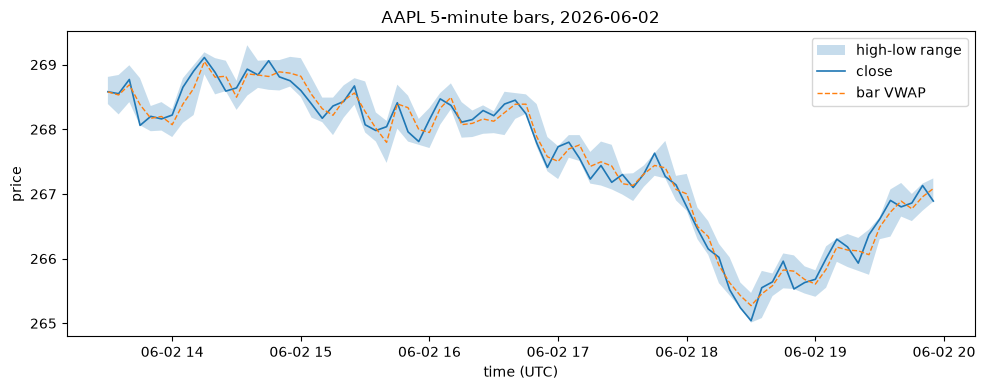

In [10]:
one_day = (
    db.table("bars_5m")
    .filter(
        col("symbol") == "AAPL",
        time_bucket("1d", col("ts")) == "2026-06-02T00:00:00Z",
    )
    .select("ts", "high", "low", "close", "vwap")
    .sort("ts")
    .to_pandas()
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(one_day["ts"], one_day["low"], one_day["high"],
                alpha=0.25, label="high-low range")
ax.plot(one_day["ts"], one_day["close"], lw=1.2, label="close")
ax.plot(one_day["ts"], one_day["vwap"], lw=1.0, ls="--", label="bar VWAP")
ax.set_title("AAPL 5-minute bars, 2026-06-02")
ax.set_xlabel("time (UTC)")
ax.set_ylabel("price")
ax.legend()
fig.tight_layout()

## 6. pandas と突き合わせる

信じてよい、ただし確かめること。同じティックから `pandas.Grouper` で5分足を作り直し、
項目ごとに比べます。どちらもタイムスタンプをバケットの先頭に切り下げ、始値と終値を
イベント順で取るので、浮動小数点の精度で一致するはずです。

In [11]:
tp = trades.to_pandas()
tp["pv"] = tp["price"] * tp["size"]
ref = (
    tp.groupby(["symbol", pd.Grouper(key="ts", freq="5min")])
    .agg(
        open=("price", "first"),
        high=("price", "max"),
        low=("price", "min"),
        close=("price", "last"),
        volume=("size", "sum"),
        pv=("pv", "sum"),
        n_trades=("price", "count"),
    )
    .reset_index()
)
ref["vwap"] = ref["pv"] / ref["volume"]

stored = db.table("bars_5m").sort(["symbol", "ts"]).to_pandas()
merged = stored.merge(ref, on=["symbol", "ts"], suffixes=("", "_ref"))
assert len(merged) == len(stored) == len(ref)
for field in ("open", "high", "low", "close", "volume", "vwap", "n_trades"):
    assert np.allclose(merged[field], merged[f"{field}_ref"]), field
print(f"all {len(merged):,} bars match pandas across OHLC, volume, VWAP, count")

all 1,170 bars match pandas across OHLC, volume, VWAP, count


## まとめ

- ティックから OHLCV と VWAP のバーまでは集約1つです。`time_bucket` と
  `.first("ts")`／`.last("ts")`、そして `vwap` が、時刻順ストレージの上をストリーミングで
  流れます。pandas の参照実装とも完全に一致しました。
- `bars(width)` という関数として書けば、どの幅のバーも、その上の行数カウントも、定義1つ
  から出てきます。SQL のテンプレートにする必要はありません。
- `time_bucket` の3つ目の引数がセッションの揃えを担当します。夏時間に強い暦日には
  `timezone=`、日付境界をまたぐ夜間セッションには `origin=`。素朴な UTC 日は Globex 型の
  セッションを黙って2つに割ります。
- 派生したバーはデータベースに置きましょう。`bars_5m` への `db.write` は、ビルド履歴を
  すべて残したままアトミックな作り直しを与えます。下流の利用者は、自分が計算に使ったバーの
  バージョンをピン留めできます。

In [12]:
db.close()